In [1]:
import math
import random

In [2]:
class Value:

    def __init__ (self,data,_children = (), _op = '', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self,other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data + other.data , (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out

    def __radd__ (self,other):
        return self + other

    def __mul__ (self,other):
        other = other if isinstance (other, Value) else Value(other)
        out = Value(self.data * other.data , (self,other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out

    def __rmul__(self,other):
        return self * other

    def __neg__ (self):
        return self * -1

    def __sub__(self,other):
        other = other if isinstance (other, Value) else Value(other)
        return self + (-other)

    def __pow__(self,power):
        out = Value(self.data ** power, (self,), f'**{power}')

        def _backward():
            self.grad += power * (self.data ** (power -1)) * out.grad
        out._backward = _backward

        return out


    def sigmoid(self):
        x = self.data
        s = 1/(1 + math.exp(-x))
        out  = Value(s, (self, ), 'sigmoid')

        def _backward():
            self.grad += (s * (1-s)) * out.grad
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) * out.grad
        out._backward = _backward

        return out

    def relu(self):
        out = Value(self.data if self.data > 0 else 0, (self, ), 'relu')

        def _backward():
            self.grad += (1.0 if self.data > 0 else 0.0) * out.grad
        out._backward = _backward

        return out
        
    

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
           if v not in visited:
             visited.add(v)
             for child in v._prev:
                 build_topo(child)
             topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
          node._backward()

In [ ]:
from graphviz import Digraph

def trace(root):
 
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) 
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      
      dot.node(name = uid + n._op, label = n._op)
      
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot 

In [ ]:
class Neuron:

    def __init__ (self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0.0)  

    def __call__ (self, x, activation='relu'):
        act = sum((wi*xi for wi,xi in zip(self.w,x)), self.b)
        if activation == 'relu':
            return act.relu()
        elif activation == 'sigmoid':
            return act.sigmoid()
        elif activation == 'tanh':
            return act.tanh()
        else:  
            return act

    def parameters (self):
        return self.w + [self.b]


class Layer:

    def __init__(self, nin, nout):
        self.neuron = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x, activation='relu'):  
        outs = [n(x, activation) for n in self.neuron]  
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neuron for p in neuron.parameters()]


class MLP:

    def __init__ (self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for i, layer in enumerate(self.layers):
           
            activation = 'linear' if i == len(self.layers) - 1 else 'tanh'
            x = layer(x, activation)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [ ]:

xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0]

n = MLP(3, [4,4,1])

In [ ]:
for k in range(50): 

   
    loss = 0
    ypred = []
    for xi, yi in zip(xs, ys):
        xi_vals = [Value(xij) for xij in xi]
        yi_val  = Value(yi)
        pred = n(xi_vals)
        ypred.append(pred)
        loss += (pred - yi_val)**2

   
    for p in n.parameters():
        p.grad = 0.0

    
    loss.backward()

    
    for p in n.parameters():
        p.data += -0.1 * p.grad

    if k % 10 == 0 or k < 5:
        print(f'step {k:3d} | loss = {loss.data:.4f} | preds = {[round(p.data,3) for p in ypred]}')


step   0 | loss = 5.7930 | preds = [0.792, 0.668, 0.631, 0.444]
step   1 | loss = 2.1282 | preds = [-0.117, -1.04, -1.361, 0.135]
step   2 | loss = 0.2765 | preds = [1.242, -0.587, -0.901, 1.194]
step   3 | loss = 0.0790 | preds = [0.862, -0.975, -1.168, 0.823]
step   4 | loss = 0.0270 | preds = [1.095, -0.896, -1.062, 1.059]
step  10 | loss = 0.0009 | preds = [1.024, -0.995, -1.016, 0.996]
step  20 | loss = 0.0002 | preds = [1.01, -1.001, -1.001, 0.991]
step  30 | loss = 0.0001 | preds = [1.007, -1.0, -1.0, 0.993]
step  40 | loss = 0.0000 | preds = [1.005, -1.0, -1.0, 0.995]


In [12]:
ypred


[Value(data = 1.003345313125441),
 Value(data = -1.0001378169171073),
 Value(data = -1.0000402873686163),
 Value(data = 0.9966815364353592)]

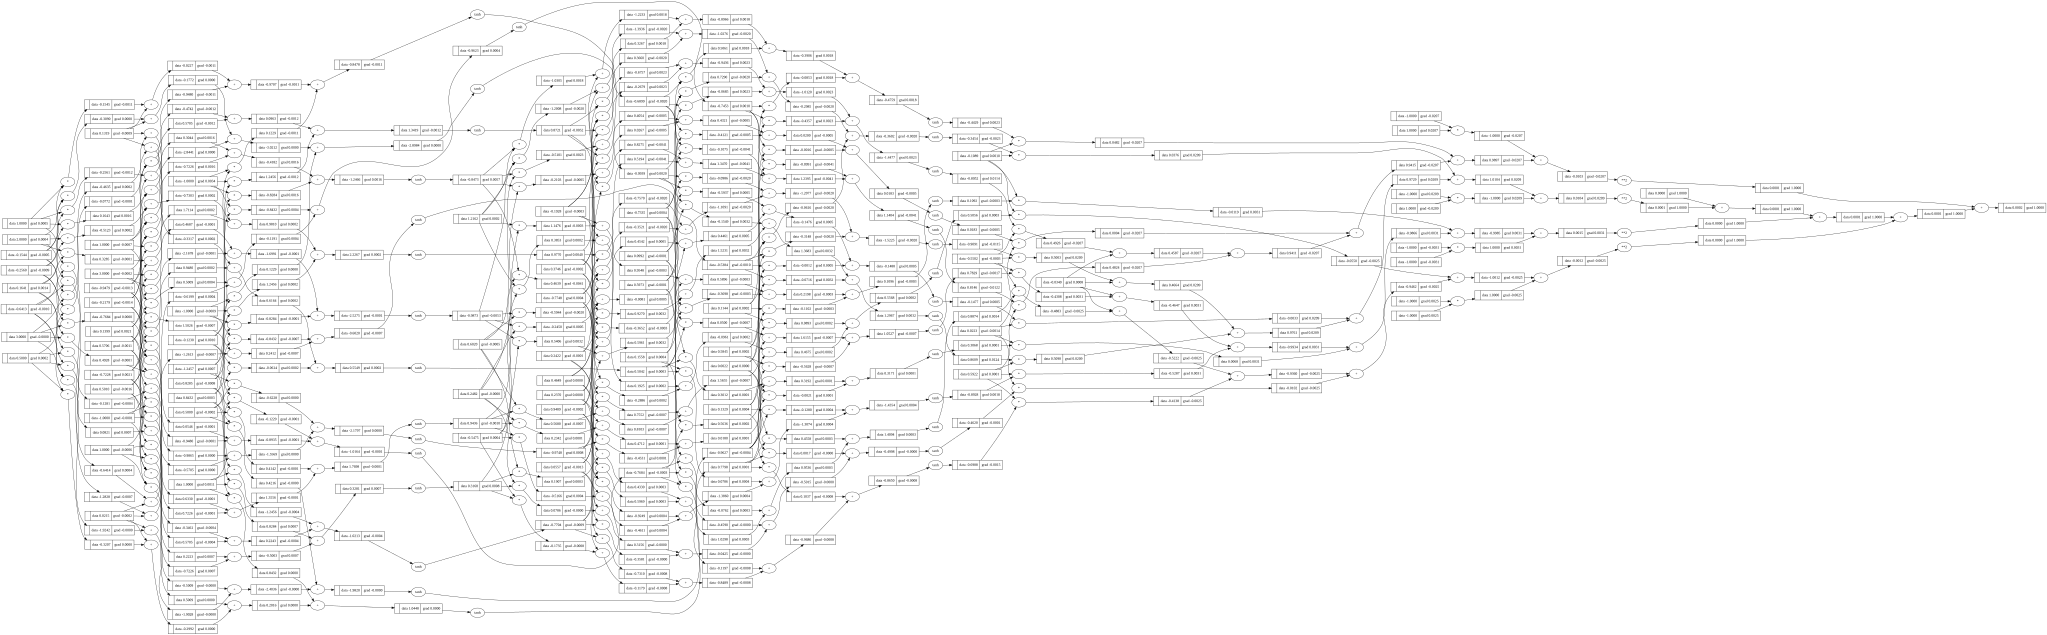

In [8]:
draw_dot(loss)
